# Framingham Heart Study: Fairness Experiments

Cardiovascular risk prediction fairness analysis using the `cvd_fairness` library.

**Experiments:**
1. Fairness trap demonstration (baseline vs naive vs constrained)
2. Sex-stratified models
3. Female-specific feature engineering (full vs lean)
3b. Automated feature selection (RFECV, maximize recall)
4. Custom feature experiments

In [1]:
from cvd_fairness import (
    prepare_data,
    get_preset_feature_sets,
    FeatureSet,
    run_experiment,
    apply_sex_specific_thresholds,
    evaluate_experiment,
    compare_experiments,
    plot_fairness_dashboard,
    plot_recall_gap,
    plot_fpr_gap,
    plot_feature_importance,
    engineer_female_features,
    FEMALE_BASE_FEATURES,
)

import warnings
warnings.filterwarnings("ignore")

df = prepare_data("framingham_heart_study.csv")
presets = get_preset_feature_sets()

print(f"Dataset: {len(df):,} participants, {df.shape[1]} columns")
print(f"Outcome prevalence: {df['TenYearCHD'].mean()*100:.1f}%")
print(f"Sex distribution: {(df['sex']==1).sum()} male, {(df['sex']==0).sum()} female")
print(f"\nPreset feature sets: {list(presets.keys())}")

Dataset: 4,240 participants, 16 columns
Outcome prevalence: 15.2%
Sex distribution: 1820 male, 2420 female

Preset feature sets: ['baseline_no_sex', 'baseline_with_sex', 'male_only', 'female_base', 'female_engineered_full', 'female_engineered_lean']


In [2]:
df.groupby('sex')['TenYearCHD'].value_counts()

sex  TenYearCHD
0    0             2119
     1              301
1    0             1477
     1              343
Name: count, dtype: int64

## 1. The Fairness Trap

Three experiments demonstrate that naively adding sex as a feature can **worsen** fairness:
- **Baseline**: Gender-blind model (no sex feature)
- **Naive**: Sex included as a feature
- **Fairness-constrained**: Sex-specific decision thresholds

In [3]:
# Run fairness trap experiments
exp_baseline = run_experiment(df, presets["baseline_no_sex"])
exp_naive = run_experiment(df, presets["baseline_with_sex"])
exp_constrained = apply_sex_specific_thresholds(exp_baseline)

fairness_results = [
    evaluate_experiment(exp_baseline),
    evaluate_experiment(exp_naive),
    evaluate_experiment(exp_constrained),
]

compare_experiments(fairness_results)

,name,overall_accuracy,overall_precision,overall_recall,overall_auc,male_accuracy,male_recall,male_fpr,female_accuracy,female_recall,female_fpr,accuracy_gap,recall_gap,fpr_gap
0,Baseline (no sex),0.658019,0.260870,0.683938,0.716442,0.653846,0.728155,0.363431,0.661157,0.633333,0.334906,0.007311,0.094822,0.028525
1,Naive (sex as feature),0.662736,0.262097,0.673575,0.724481,0.595238,0.805825,0.453725,0.713499,0.522222,0.259434,0.118261,0.283603,0.194291
2,Baseline (no sex) (fairness-constrained),0.658019,0.258964,0.673575,0.716442,0.659341,0.708738,0.352144,0.657025,0.633333,0.339623,0.002316,0.075405,0.012522


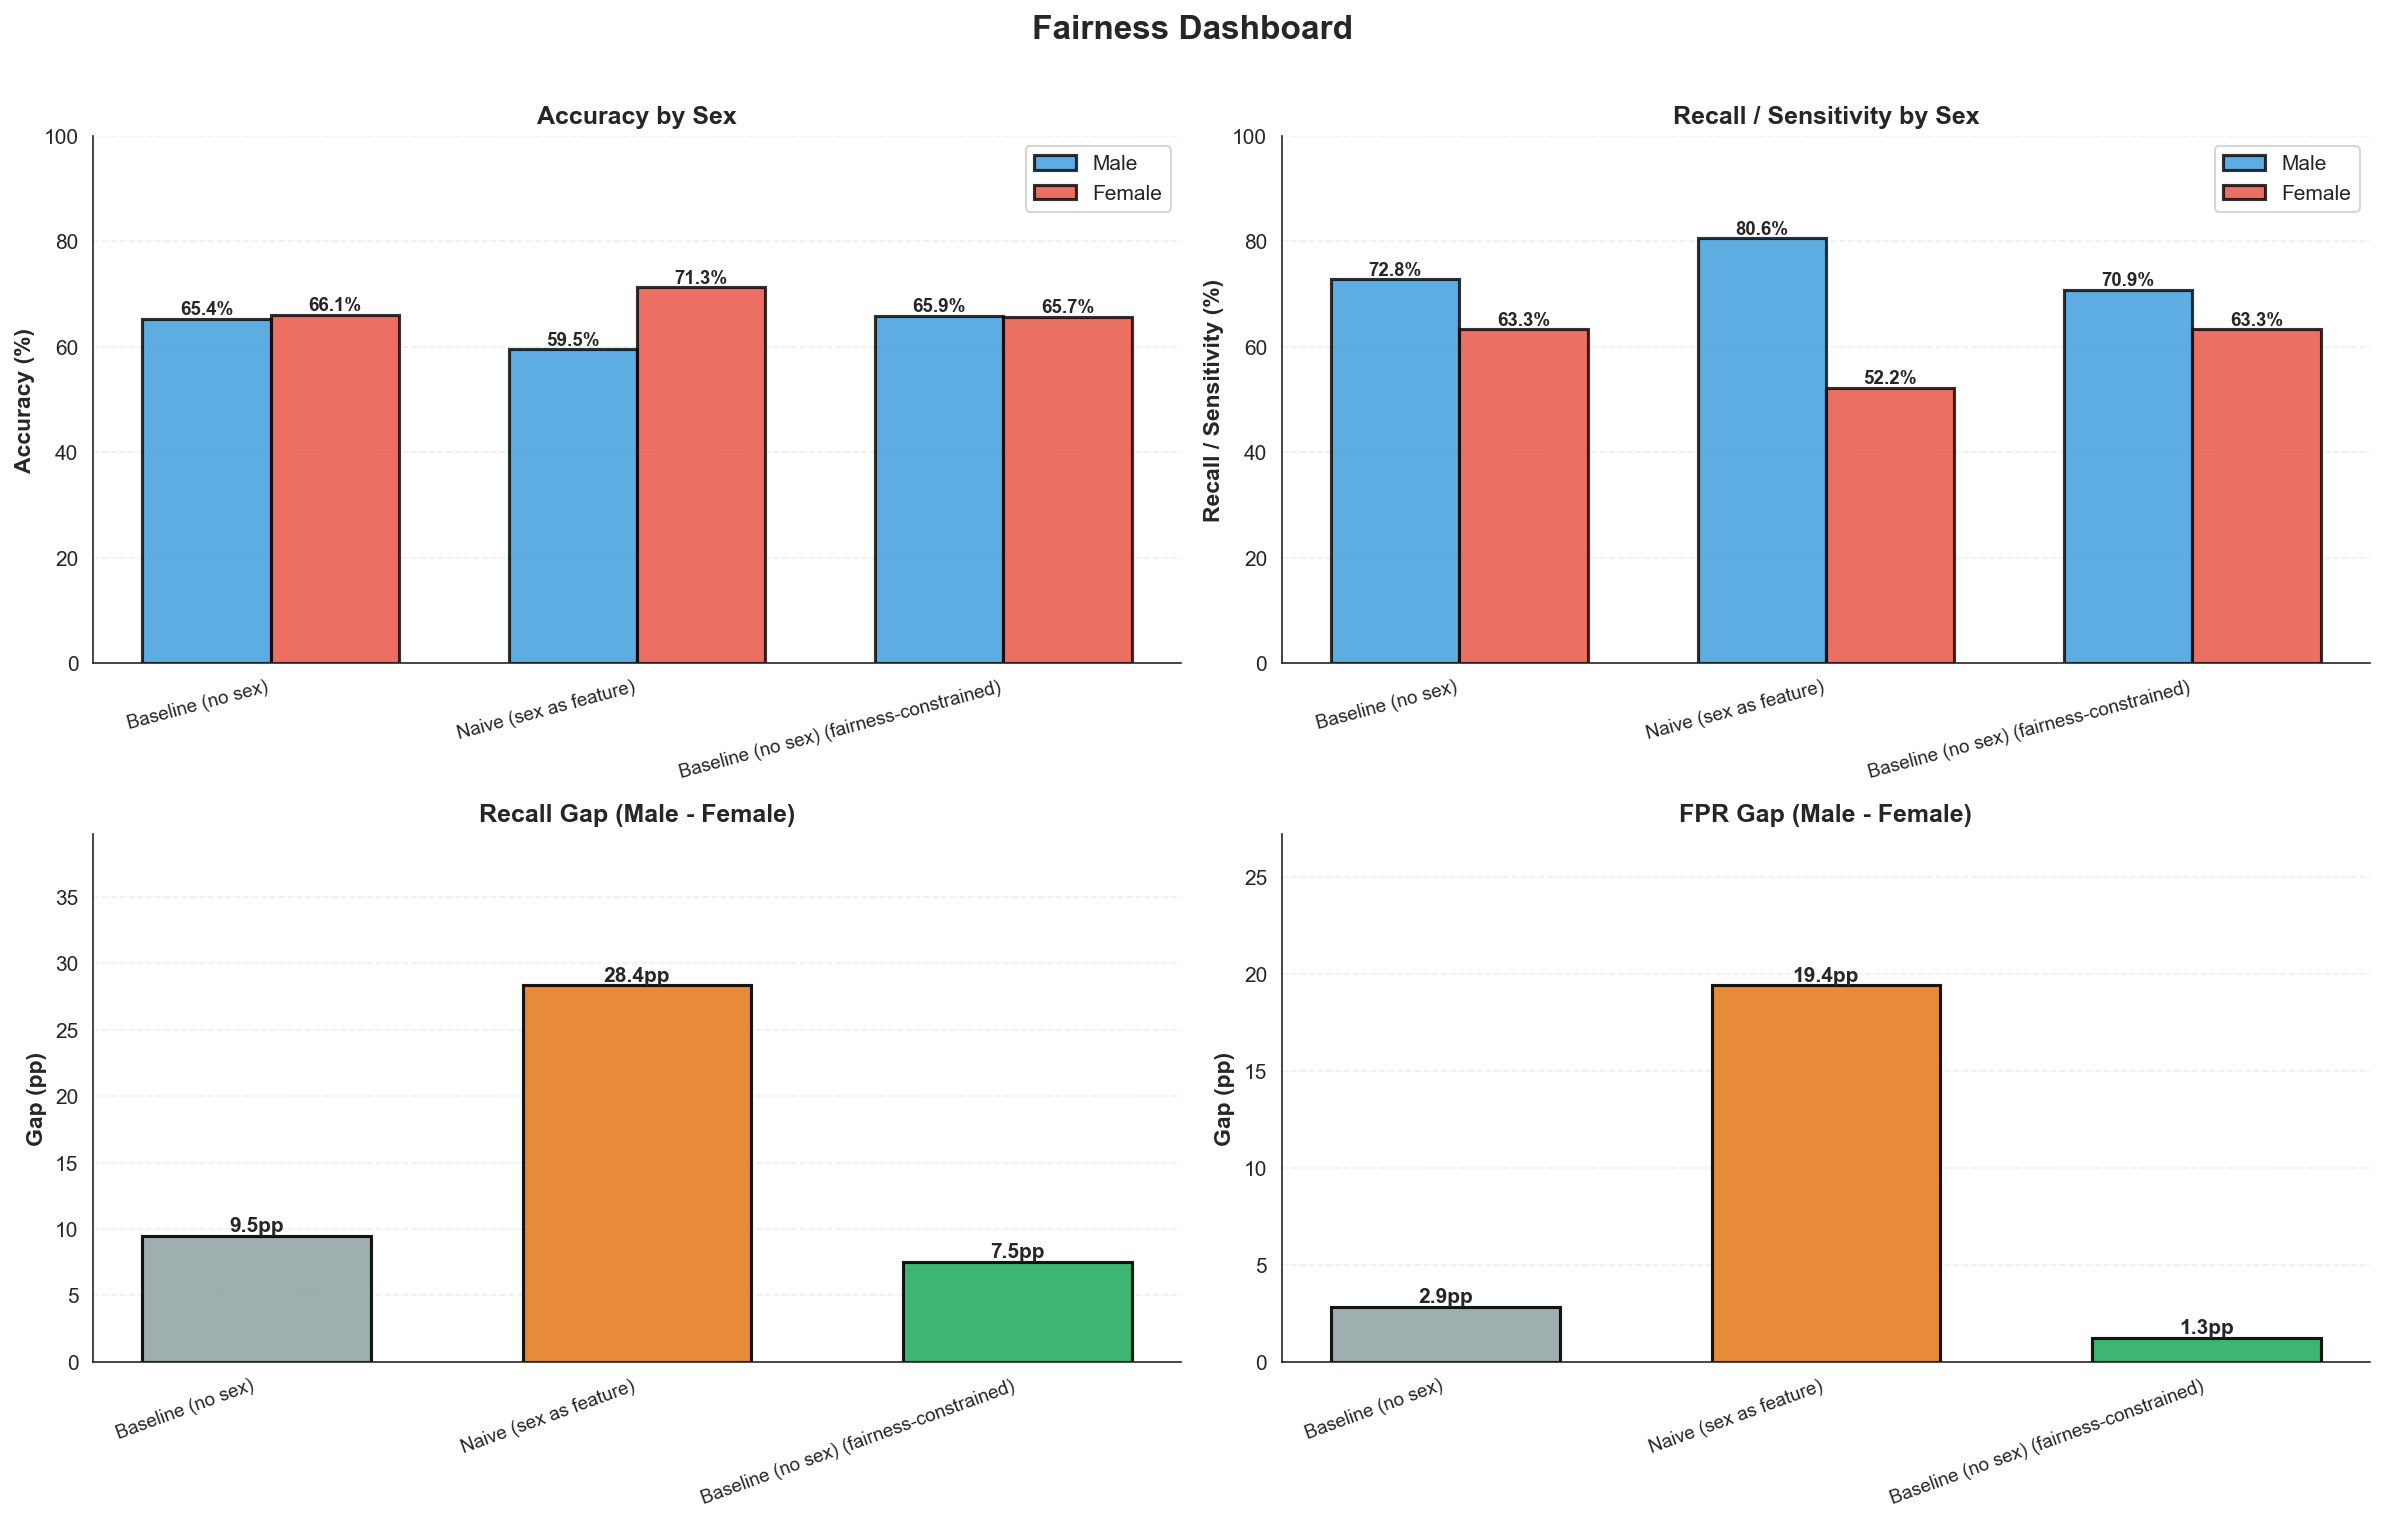

In [4]:
plot_fairness_dashboard(fairness_results)

## 2. Sex-Stratified Models

Train separate models for males and females — each learns sex-specific risk patterns.

In [5]:
# Sex-stratified models
exp_male = run_experiment(df, presets["male_only"])
exp_female_base = run_experiment(df, presets["female_base"])

stratified_results = [
    evaluate_experiment(exp_male),
    evaluate_experiment(exp_female_base),
]

compare_experiments(stratified_results)

,name,overall_accuracy,overall_precision,overall_recall,overall_auc,accuracy_gap,recall_gap,fpr_gap
0,Male-only baseline,0.683150,0.331731,0.669903,0.728199,None,None,None
1,Female baseline,0.662534,0.214022,0.644444,0.707879,None,None,None


## 3. Female Feature Engineering

Purpose-built models with features designed for female physiology:
- **Female baseline**: Standard risk factors only
- **Full engineered**: + 15 female-specific features (menopause, cholesterol interactions, metabolic syndrome, risk amplification)
- **Lean engineered**: + 5 highest-impact features

In [6]:
# Female feature engineering experiments
female_results = []
for name in ["female_base", "female_engineered_full", "female_engineered_lean"]:
    exp = run_experiment(df, presets[name])
    female_results.append(evaluate_experiment(exp))

compare_experiments(female_results)

,name,overall_accuracy,overall_precision,overall_recall,overall_auc,accuracy_gap,recall_gap,fpr_gap
0,Female baseline,0.662534,0.214022,0.644444,0.707879,None,None,None
1,Female engineered (full),0.663912,0.212687,0.633333,0.719811,None,None,None
2,Female engineered (lean),0.663912,0.216912,0.655556,0.723235,None,None,None


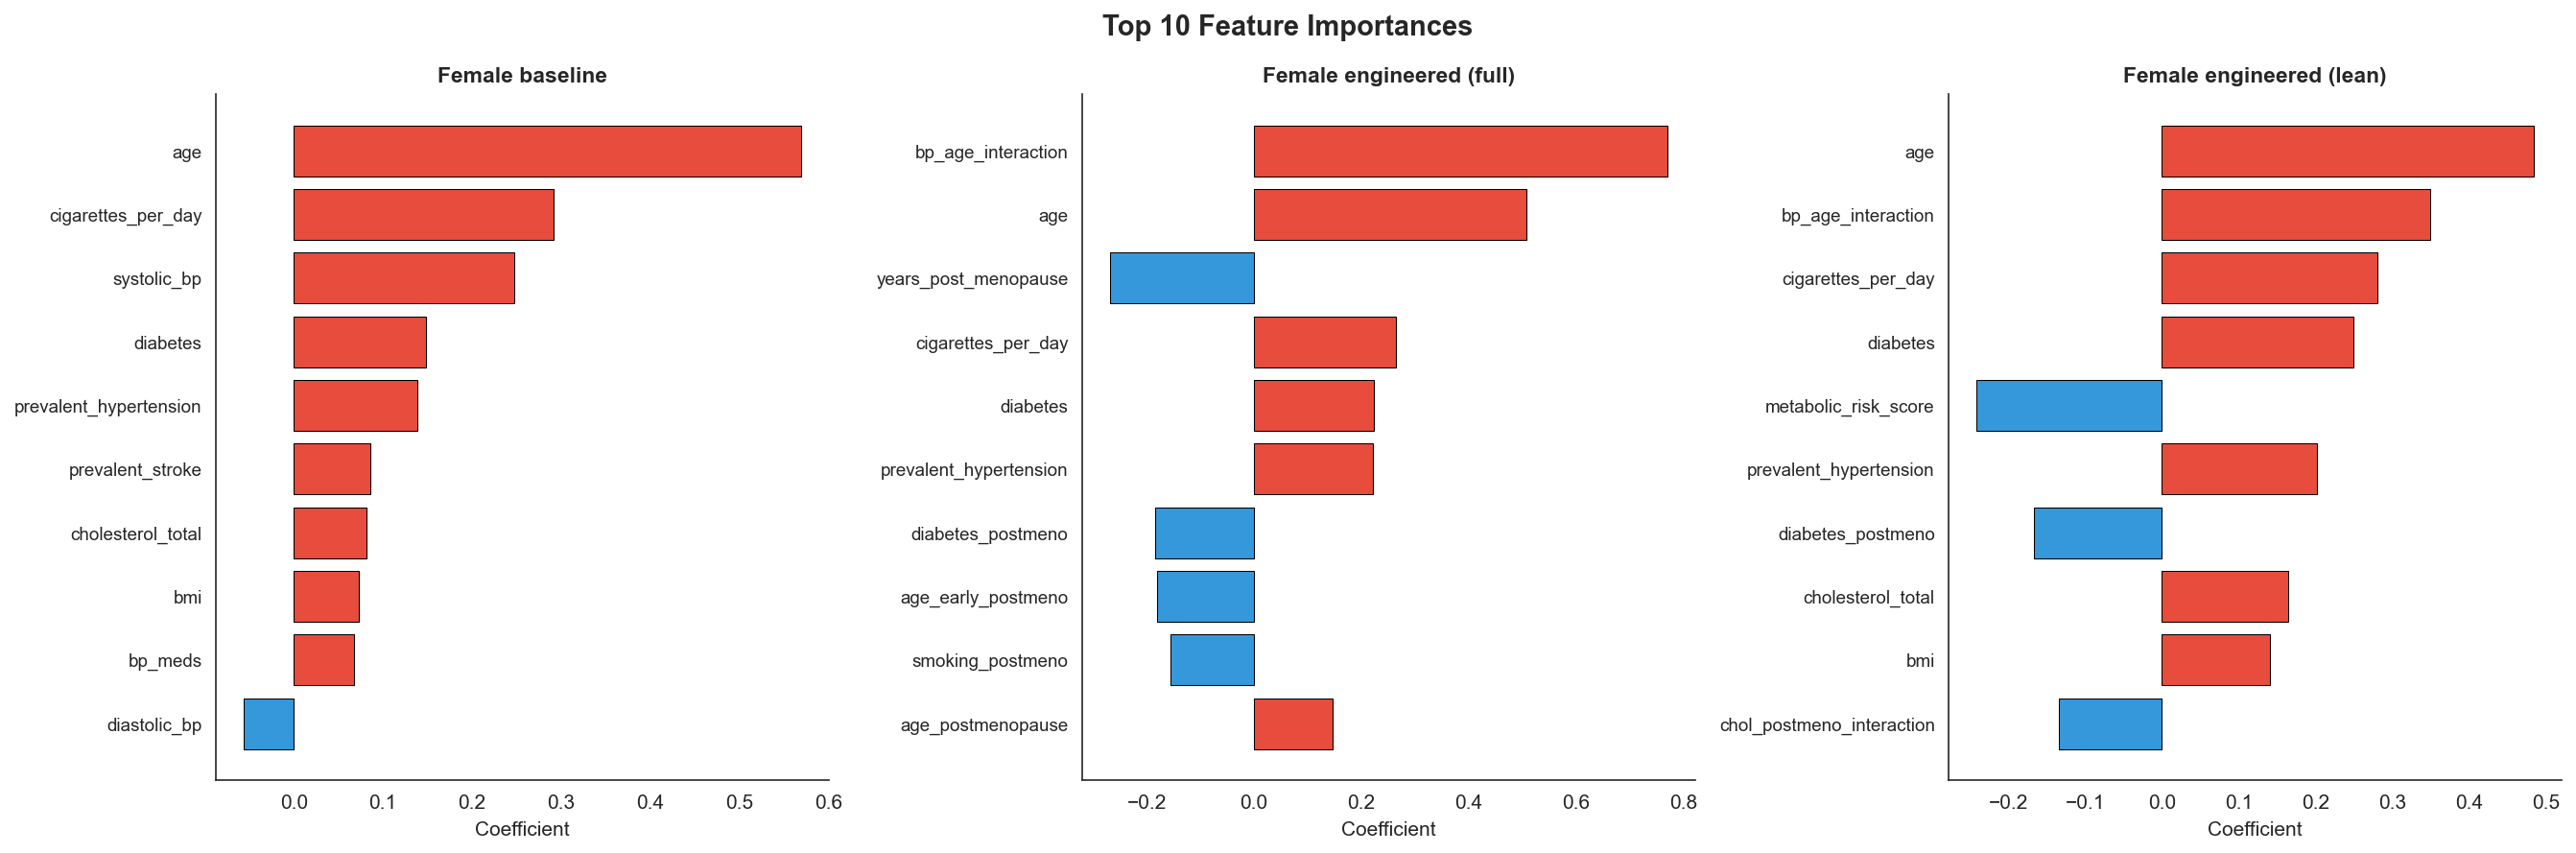

In [8]:
plot_feature_importance(female_results, top_n=10)

## 3b. Automated Feature Selection (maximize recall)

Use RFECV (Recursive Feature Elimination with Cross-Validation) to find the optimal
subset of the full 27 engineered features that maximizes recall.

In [15]:
from cvd_fairness import select_features

# Run RFECV on the full engineered feature set, optimizing for recall
selection = select_features(
    df,
    presets["female_engineered_full"],
    scoring="recall",
    method="rfecv",
    cv=5,
)

print(f"Selected {len(selection.selected_features)} / {len(presets['female_engineered_full'].features)} features\n")
print("Feature ranking:")
print(selection.ranking.to_string(index=False))
print(f"\nSelected features:\n  {selection.selected_features}")

Selected 8 / 27 features

Feature ranking:
                  feature  rank
        age_postmenopause     1
        cholesterol_total     1
              systolic_bp     1
      hypertension_stage2     1
           chol_age_ratio     1
chol_postmeno_interaction     1
       cigarettes_per_day     1
   prevalent_hypertension     1
       age_early_postmeno     2
     years_post_menopause     3
                      age     4
                 diabetes     5
        diabetes_postmeno     6
                  glucose     7
     triple_risk_postmeno     8
        prediabetic_range     9
                  obesity    10
                      bmi    11
       high_chol_postmeno    12
         smoking_postmeno    13
                  bp_meds    14
         prevalent_stroke    15
             diastolic_bp    16
     metabolic_risk_score    17
                   smoker    18
       bp_age_interaction    19
        age_perimenopause    20

Selected features:
  ['cholesterol_total', 'systolic_bp', 'c

In [16]:
selection.feature_set

FeatureSet(name='Female engineered (full) (selected 8)', features=['cholesterol_total', 'systolic_bp', 'cigarettes_per_day', 'prevalent_hypertension', 'age_postmenopause', 'chol_postmeno_interaction', 'chol_age_ratio', 'hypertension_stage2'], engineer_fn=<function engineer_female_features at 0x127853950>, sex_filter=0, outcome='TenYearCHD', description='Feature selection (rfecv, scoring=recall) from Female engineered (full)')

In [17]:
df

,sex,age,education,smoker,cigarettes_per_day,bp_meds,prevalent_stroke,prevalent_hypertension,diabetes,cholesterol_total,systolic_bp,diastolic_bp,bmi,heart_rate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [18]:
# Run an experiment with the selected features and compare
exp_selected = run_experiment(df, selection.feature_set)

all_female = [
    evaluate_experiment(run_experiment(df, presets["female_base"])),
    evaluate_experiment(run_experiment(df, presets["female_engineered_full"])),
    evaluate_experiment(run_experiment(df, presets["female_engineered_lean"])),
    evaluate_experiment(exp_selected),
]

compare_experiments(all_female)

,name,overall_accuracy,overall_precision,overall_recall,overall_auc,accuracy_gap,recall_gap,fpr_gap
0,Female baseline,0.662534,0.214022,0.644444,0.707879,None,None,None
1,Female engineered (full),0.659780,0.210332,0.633333,0.720161,None,None,None
2,Female engineered (lean),0.663912,0.216912,0.655556,0.723235,None,None,None
3,Female engineered (full) (selected 8),0.641873,0.210884,0.688889,0.728651,None,None,None


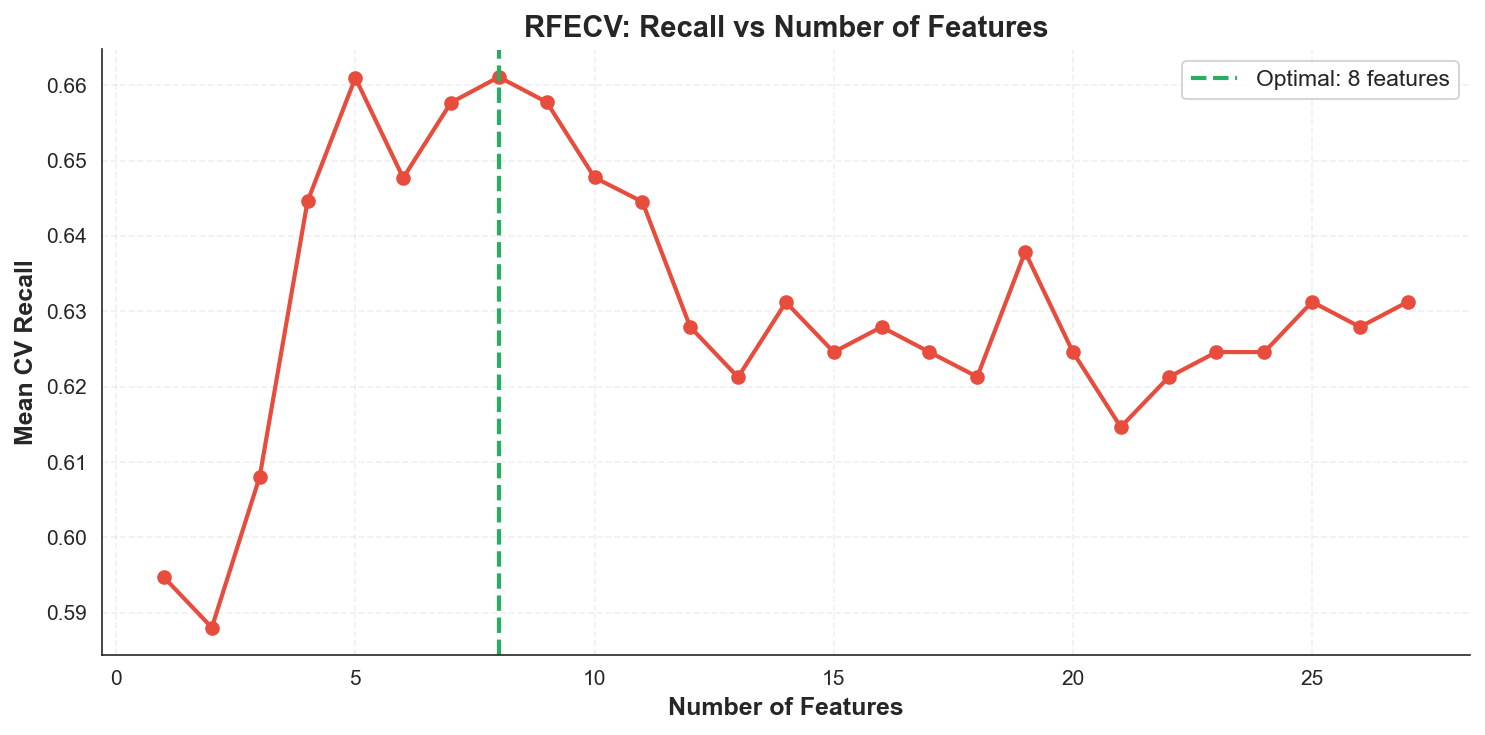

In [19]:
# Visualize CV recall score vs number of features
import matplotlib.pyplot as plt

n_features = sorted(selection.cv_scores.keys())
scores = [selection.cv_scores[n] for n in n_features]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_features, scores, "o-", color="#e74c3c", linewidth=2, markersize=6)
ax.axvline(len(selection.selected_features), color="#27ae60", linestyle="--", linewidth=2,
           label=f"Optimal: {len(selection.selected_features)} features")
ax.set_xlabel("Number of Features", fontsize=12, fontweight="bold")
ax.set_ylabel("Mean CV Recall", fontsize=12, fontweight="bold")
ax.set_title("RFECV: Recall vs Number of Features", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

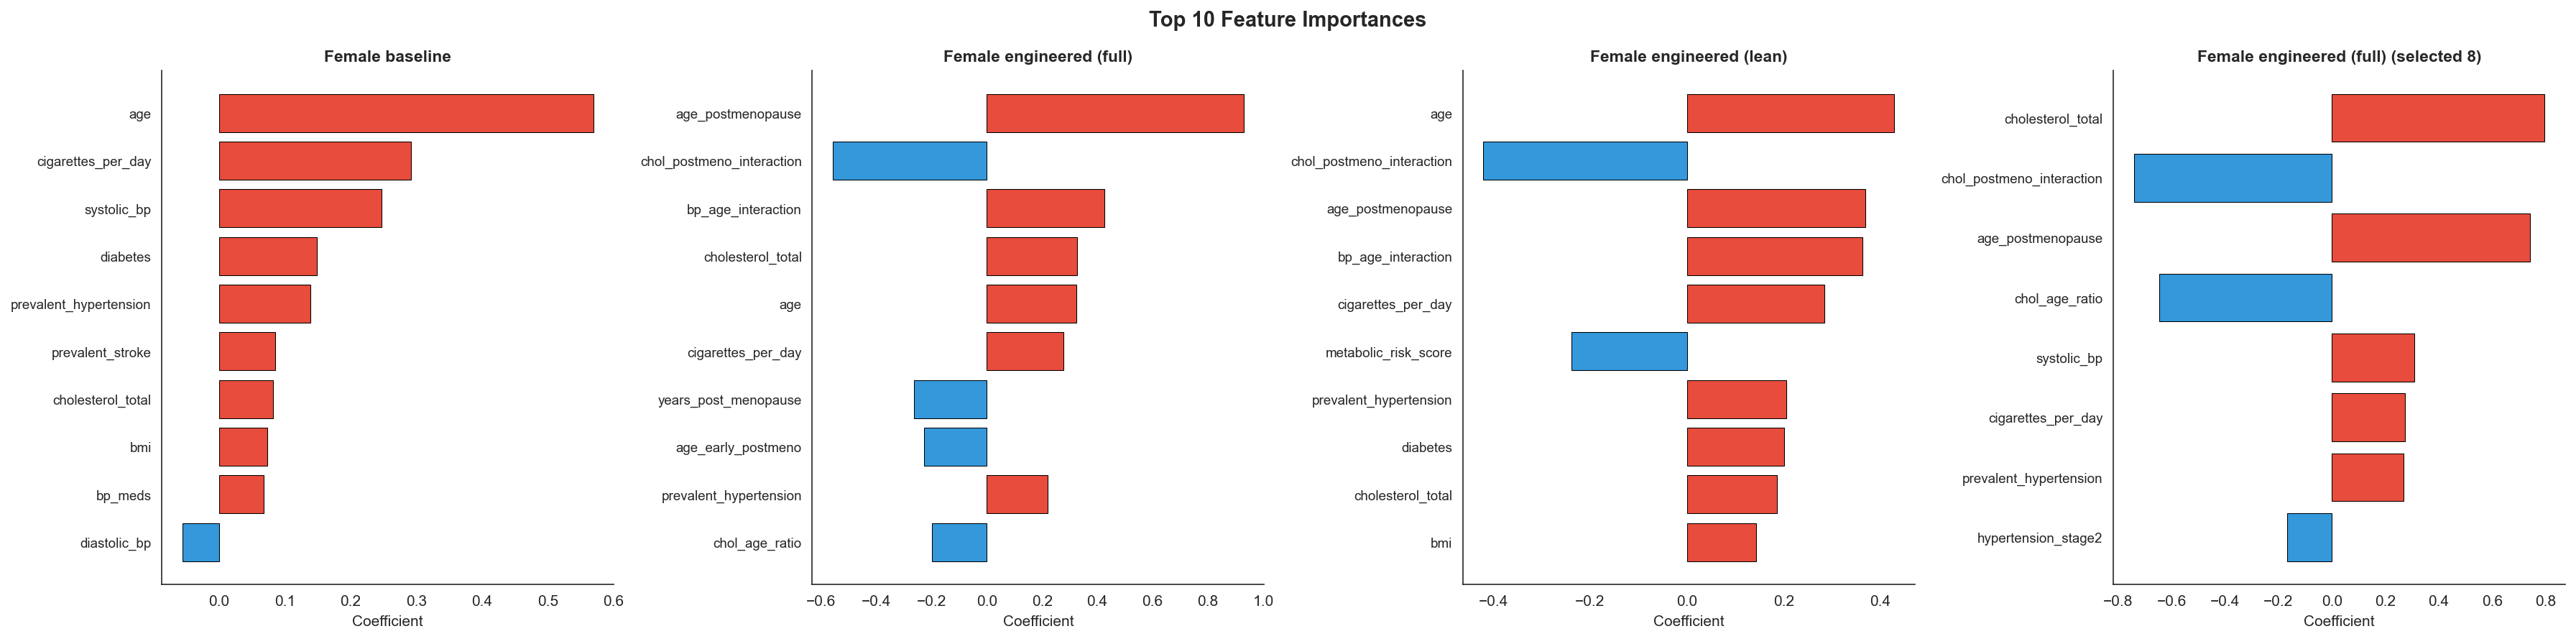

In [20]:
plot_feature_importance(all_female, top_n=10)

## 4. Custom Feature Experiments

Define your own `FeatureSet` to test any combination of features.

In [7]:
# Example: test just menopause + metabolic score
custom = FeatureSet(
    name="Menopause + metabolic",
    features=FEMALE_BASE_FEATURES + ["age_postmenopause", "metabolic_risk_score"],
    engineer_fn=engineer_female_features,
    sex_filter=0,
    description="Base + menopause proxy + metabolic risk score only",
)

exp_custom = run_experiment(df, custom)
female_results.append(evaluate_experiment(exp_custom))

compare_experiments(female_results)

,name,overall_accuracy,overall_precision,overall_recall,overall_auc,accuracy_gap,recall_gap,fpr_gap
0,Female baseline,0.662534,0.214022,0.644444,0.707879,None,None,None
1,Female engineered (full),0.659780,0.210332,0.633333,0.720161,None,None,None
2,Female engineered (lean),0.663912,0.216912,0.655556,0.723235,None,None,None
3,Menopause + metabolic,0.661157,0.211111,0.633333,0.715636,None,None,None


In [8]:
FEMALE_BASE_FEATURES

['age',
 'cholesterol_total',
 'systolic_bp',
 'diastolic_bp',
 'glucose',
 'diabetes',
 'bmi',
 'smoker',
 'cigarettes_per_day',
 'bp_meds',
 'prevalent_hypertension',
 'prevalent_stroke']

In [10]:
presets['female_engineered_lean'].features

['age',
 'cholesterol_total',
 'systolic_bp',
 'diastolic_bp',
 'glucose',
 'diabetes',
 'bmi',
 'smoker',
 'cigarettes_per_day',
 'bp_meds',
 'prevalent_hypertension',
 'prevalent_stroke',
 'age_postmenopause',
 'chol_postmeno_interaction',
 'metabolic_risk_score',
 'diabetes_postmeno',
 'bp_age_interaction']

In [11]:
custom_features = ['age',
 'glucose',
 'diabetes',
 'smoker',
 'cigarettes_per_day',
 'bp_meds',
 'prevalent_stroke',
 'age_postmenopause',
 'chol_postmeno_interaction',
 'metabolic_risk_score',
 'diabetes_postmeno',
 'bp_age_interaction']

In [12]:
# Example: test just menopause + metabolic score
custom = FeatureSet(
    name="Min features",
    features=custom_features,
    engineer_fn=engineer_female_features,
    sex_filter=0,
    description="Reduce collinearity of features",
)

exp_custom = run_experiment(df, custom)
female_results.append(evaluate_experiment(exp_custom))

compare_experiments(female_results)

,name,overall_accuracy,overall_precision,overall_recall,overall_auc,accuracy_gap,recall_gap,fpr_gap
0,Female baseline,0.662534,0.214022,0.644444,0.707879,None,None,None
1,Female engineered (full),0.659780,0.210332,0.633333,0.720161,None,None,None
2,Female engineered (lean),0.663912,0.216912,0.655556,0.723235,None,None,None
3,Menopause + metabolic,0.661157,0.211111,0.633333,0.715636,None,None,None
4,Min features,0.669421,0.209302,0.600000,0.712089,None,None,None


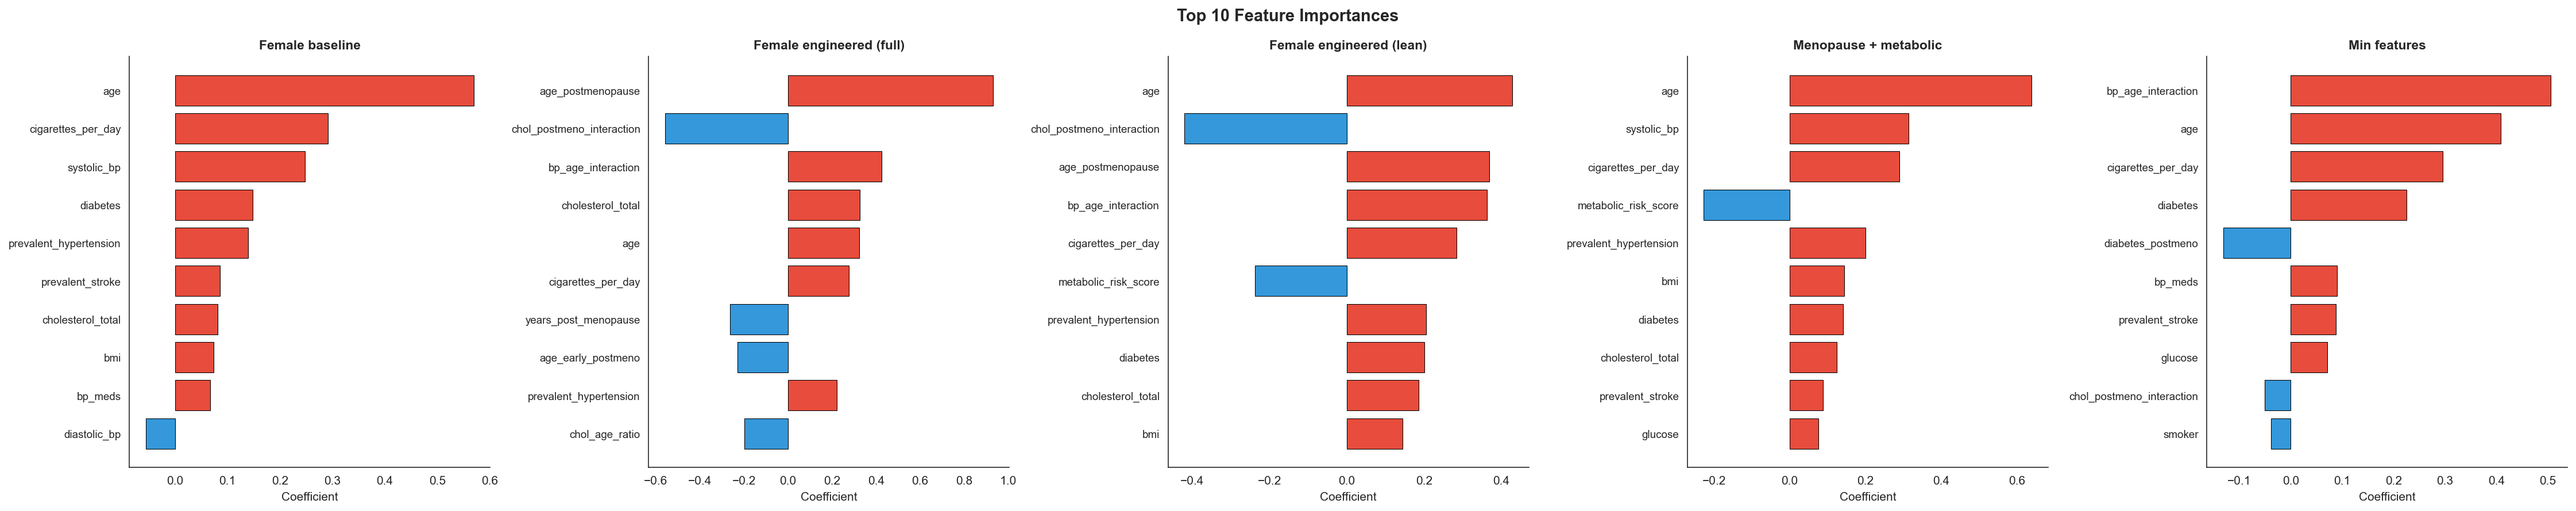

In [13]:
plot_feature_importance(female_results, top_n=10)

In [15]:
presets['female_engineered_full'].features

['age',
 'cholesterol_total',
 'systolic_bp',
 'diastolic_bp',
 'glucose',
 'diabetes',
 'bmi',
 'smoker',
 'cigarettes_per_day',
 'bp_meds',
 'prevalent_hypertension',
 'prevalent_stroke',
 'age_perimenopause',
 'age_postmenopause',
 'age_early_postmeno',
 'years_post_menopause',
 'chol_postmeno_interaction',
 'high_chol_postmeno',
 'chol_age_ratio',
 'obesity',
 'prediabetic_range',
 'hypertension_stage2',
 'metabolic_risk_score',
 'diabetes_postmeno',
 'smoking_postmeno',
 'triple_risk_postmeno',
 'bp_age_interaction']

In [16]:
custom_2 = [
#    'age',
# 'cholesterol_total',
# 'systolic_bp',
# 'diastolic_bp',
 'glucose',
 'diabetes',
# 'bmi',
# 'smoker',
 'cigarettes_per_day',
 'bp_meds',
 'prevalent_hypertension',
 'prevalent_stroke',
# 'age_perimenopause',
# 'age_postmenopause',
# 'age_early_postmeno',
 'years_post_menopause',
 'chol_postmeno_interaction',
# 'high_chol_postmeno',
 'chol_age_ratio',
# 'obesity',
# 'prediabetic_range',
# 'hypertension_stage2',
 'metabolic_risk_score',
# 'diabetes_postmeno',
# 'smoking_postmeno',
# 'triple_risk_postmeno',
 'bp_age_interaction']

In [17]:
# Example: test just menopause + metabolic score
custom = FeatureSet(
    name="Min features",
    features=custom_2,
    engineer_fn=engineer_female_features,
    sex_filter=0,
    description="Reduce collinearity of features",
)

exp_custom = run_experiment(df, custom)
female_results.append(evaluate_experiment(exp_custom))

compare_experiments(female_results)

,name,overall_accuracy,overall_precision,overall_recall,overall_auc,accuracy_gap,recall_gap,fpr_gap
0,Female baseline,0.662534,0.214022,0.644444,0.707879,None,None,None
1,Female engineered (full),0.659780,0.210332,0.633333,0.720161,None,None,None
2,Female engineered (lean),0.663912,0.216912,0.655556,0.723235,None,None,None
3,Menopause + metabolic,0.661157,0.211111,0.633333,0.715636,None,None,None
4,Min features,0.669421,0.209302,0.600000,0.712089,None,None,None
5,Min features,0.691460,0.223140,0.600000,0.705328,None,None,None


---

# Summary: The Fairness Trap in Cardiovascular Risk Prediction

## Dataset

Framingham Heart Study — 4,240 participants (1,820 male, 2,420 female) with 10-year coronary heart disease outcomes (15.2% prevalence). The gold standard for cardiovascular risk prediction.

---

## Experiment 1: The Fairness Trap

We trained three logistic regression models to predict 10-year CVD risk and measured **recall** (sensitivity — the fraction of actual CVD cases correctly identified) stratified by sex.

| Model | Overall Recall | Male Recall | Female Recall | Recall Gap |
|-------|---------------|-------------|---------------|------------|
| **Baseline** (no sex feature) | 68.4% | 72.8% | 63.3% | 9.5pp |
| **Naive** (sex as feature) | 67.4% | 80.6% | 52.2% | **28.4pp** |
| **Fairness-constrained** (sex-specific thresholds) | 67.4% | 70.9% | 63.3% | 7.5pp |

**The trap:** Adding sex as a feature *tripled* the recall gap (9.5pp to 28.4pp). The model learned to over-predict for men and under-predict for women — missing nearly half of women's CVD cases. Meanwhile, male false positive rates jumped to 45%, meaning unnecessary testing and anxiety.

The fairness-constrained approach (same model, sex-specific decision thresholds) reduced the gap to 7.5pp without sacrificing overall performance.

---

## Experiment 2: Sex-Stratified Models

Training separate models for each sex sidesteps the fairness trap entirely.

| Model | Recall | Accuracy | AUC |
|-------|--------|----------|-----|
| Male-only model | 67.0% | 68.3% | 0.728 |
| Female-only model | 64.4% | 66.3% | 0.708 |

Each model learns population-specific patterns. The female model's lower recall motivates the next step: engineering features designed for female physiology.

---

## Experiment 3: Female-Specific Feature Engineering

We engineered 15 features capturing women-specific CVD risk patterns across four domains:

- **Menopause proxies:** perimenopause (45-54), post-menopause (55+), years since menopause
- **Cholesterol-age interactions:** post-menopausal cholesterol impact, high cholesterol + post-menopause
- **Metabolic syndrome:** obesity, pre-diabetic range, hypertension stage 2, composite metabolic score
- **Risk amplification:** diabetes + post-menopause, smoking + post-menopause, triple risk

| Model | Features | Recall | AUC |
|-------|----------|--------|-----|
| Female baseline | 12 standard | 64.4% | 0.708 |
| Full engineered | 12 + 15 engineered = 27 | 63.3% | 0.720 |
| Lean engineered | 12 + 5 top engineered = 17 | 65.6% | 0.723 |

The full set of 27 features introduced noise — AUC improved but recall dropped. The lean set (5 carefully chosen features) improved both recall and AUC over baseline.

---

## Experiment 4: Automated Feature Selection (RFECV)

We used Recursive Feature Elimination with Cross-Validation (RFECV), scoring by recall, to find the optimal subset from the 27-feature pool.

**RFECV selected 8 features:**

| Selected Feature | Domain |
|-----------------|--------|
| cholesterol_total | Lipid panel |
| systolic_bp | Blood pressure |
| cigarettes_per_day | Lifestyle |
| prevalent_hypertension | Medical history |
| age_postmenopause | Menopause proxy |
| chol_postmeno_interaction | Cholesterol-age interaction |
| chol_age_ratio | Cholesterol-age interaction |
| hypertension_stage2 | Metabolic syndrome |

| Model | Features | Recall | AUC |
|-------|----------|--------|-----|
| Female baseline | 12 | 64.4% | 0.708 |
| Lean engineered | 17 | 65.6% | 0.723 |
| **RFECV-selected** | **8** | **68.9%** | **0.729** |

The RFECV-selected model achieves the highest recall (68.9%) with fewer than one-third of the full feature set. It correctly identifies nearly 7 in 10 women who will develop CVD within 10 years, compared to roughly 6 in 10 with the standard model — using only 8 features.

---

## Key Takeaways

1. **The fairness trap is real.** Adding sex as a feature tripled the recall gap. The "obvious" solution made things worse.

2. **Feature engineering matters more than feature quantity.** 27 features performed worse than 8 carefully selected ones. More features introduced noise and collinearity.

3. **Post-menopausal status is the single most important engineered feature.** It appeared in every top-performing subset — menopause is a cardiovascular inflection point that age alone does not capture.

4. **Cholesterol-age interactions are key for women.** The combination of cholesterol with post-menopausal status (`chol_postmeno_interaction`) was selected by RFECV — cholesterol's impact on CVD risk changes fundamentally after menopause.

5. **Women's health ML needs purpose-built features,** not male-normed models with sex adjustments. Just as ovarian reserve markers capture reproductive biology better than chronological age, menopause-aware cardiovascular features capture female CVD risk better than standard risk factors alone.